In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Replace 'path/to/your/file.csv' with the actual path to your file in Google Drive
# Example: file_path = '/content/drive/MyDrive/my_folder/my_data.csv'
file_path = '/content/drive/MyDrive/colab_notebooks/developers_institute/datascience_salaries.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}. First 5 rows:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded data from /content/drive/MyDrive/colab_notebooks/developers_institute/datascience_salaries.csv. First 5 rows:


,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


In [5]:
# Create a copy of the DataFrame to work with
df_copy = df.copy()
print("Created a copy of the DataFrame named 'df_copy'.")


Created a copy of the DataFrame named 'df_copy'.


In [7]:
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler and transform the 'salary' column of df_copy
scaler = MinMaxScaler()
df_copy['salary_normalized'] = scaler.fit_transform(df_copy[['salary']])

# Display the first few rows of df_copy with the new normalized column
print("DataFrame 'df_copy' after Min-Max normalization of 'salary' column using MinMaxScaler:")
display(df_copy.head())

DataFrame 'df_copy' after Min-Max normalization of 'salary' column using MinMaxScaler:


,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary,salary_normalized
0,0,Data scientist,Full Time,Senior,New York City,USD,149000,0.601010
1,2,Data scientist,Full Time,Senior,Boston,USD,120000,0.454545
2,3,Data scientist,Full Time,Senior,London,USD,68000,0.191919
3,4,Data scientist,Full Time,Senior,Boston,USD,120000,0.454545
4,5,Data scientist,Full Time,Senior,New York City,USD,149000,0.601010


In [10]:
import pandas as pd

# Select categorical features to one-hot encode
categorical_features_for_ohe = ['job_type', 'experience_level']

# Check if these columns exist in df_copy before encoding
actual_categorical_features = [col for col in categorical_features_for_ohe if col in df_copy.columns]

if not actual_categorical_features:
    print("No suitable categorical features found for one-hot encoding. Please check your DataFrame columns.")
else:
    print(f"Categorical features selected for one-hot encoding: {actual_categorical_features}")
    # Apply one-hot encoding
    df_encoded = pd.get_dummies(df_copy[actual_categorical_features], drop_first=True)

    # Concatenate the one-hot encoded features with the original df_copy (excluding original categorical columns)
    df_copy_pca_ready = pd.concat([df_copy.drop(columns=actual_categorical_features), df_encoded], axis=1)

    print("DataFrame after one-hot encoding:")
    display(df_copy_pca_ready.head())

    # Update the global df_copy for subsequent PCA steps to use this new DataFrame
    df_copy = df_copy_pca_ready.copy()
    print("Updated 'df_copy' with one-hot encoded features.")

Categorical features selected for one-hot encoding: ['job_type', 'experience_level']
DataFrame after one-hot encoding:


,Unnamed: 0,job_title,location,salary_currency,salary,salary_normalized,job_type_Internship,experience_level_Executive,experience_level_Mid,experience_level_Senior
0,0,Data scientist,New York City,USD,149000,0.601010,False,False,False,True
1,2,Data scientist,Boston,USD,120000,0.454545,False,False,False,True
2,3,Data scientist,London,USD,68000,0.191919,False,False,False,True
3,4,Data scientist,Boston,USD,120000,0.454545,False,False,False,True
4,5,Data scientist,New York City,USD,149000,0.601010,False,False,False,True


Updated 'df_copy' with one-hot encoded features.


In [15]:
from sklearn.preprocessing import StandardScaler

# Identify all numerical columns in the updated df_copy for PCA
# This will include 'salary_normalized' and all one-hot encoded columns (which are boolean/numerical)

# Exclude non-numerical columns and original categorical columns that were encoded
# The updated df_copy should already have these removed, but let's be explicit.

# Get all numerical columns. Pandas dtypes 'bool' will be treated as numerical (0s and 1s).
# We should also exclude any original identifier columns like 'Unnamed: 0'

columns_to_exclude = ['Unnamed: 0', 'job_title', 'location', 'salary_currency', 'salary']

# Get all columns from df_copy_pca_ready that are numerical (including booleans from OHE)
numerical_features_for_pca = df_copy.select_dtypes(include=['number', 'bool']).columns.tolist()

# Filter out any columns that should not be used for PCA (like original identifiers or raw salary)
actual_numerical_features_for_pca = [col for col in numerical_features_for_pca if col not in columns_to_exclude]

if not actual_numerical_features_for_pca:
    print("No suitable numerical features found for PCA after one-hot encoding. Please check your DataFrame.")
else:
    print(f"Features selected for PCA: {actual_numerical_features_for_pca}")
    X = df_copy[actual_numerical_features_for_pca].copy()

    # Standardize the features
    scaler_pca = StandardScaler()
    X_scaled = scaler_pca.fit_transform(X)

    print("Features standardized.")
    # Display first few rows of scaled data (optional)
    # display(pd.DataFrame(X_scaled, columns=actual_numerical_features_for_pca).head())


Features selected for PCA: ['salary_normalized', 'job_type_Internship', 'experience_level_Executive', 'experience_level_Mid', 'experience_level_Senior']
Features standardized.


Explained variance ratio per principal component:
PC1: 0.3959
PC2: 0.2072
PC3: 0.2000
PC4: 0.1595
PC5: 0.0374

Cumulative explained variance:
PC1 (Cumulative): 0.3959
PC2 (Cumulative): 0.6031
PC3 (Cumulative): 0.8031
PC4 (Cumulative): 0.9626
PC5 (Cumulative): 1.0000


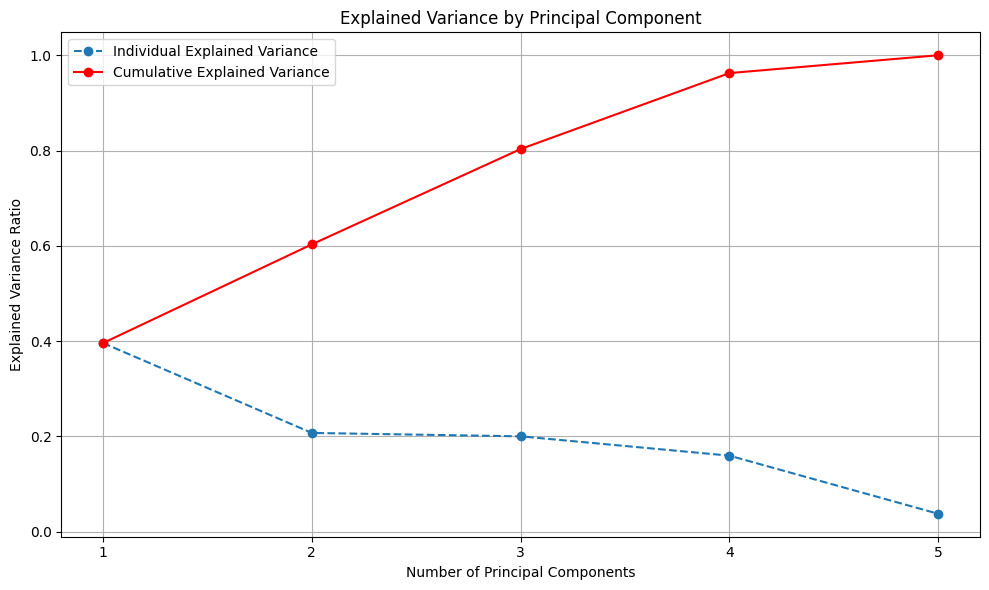


Number of components to retain for 95% cumulative variance: 4 (adjust as needed)

Shape of data after PCA with 4 components: (1171, 4)
First 5 rows of the transformed data (Principal Components):


,PC1,PC2,PC3,PC4
0,1.994865,0.362872,-0.210382,1.857893
1,1.616811,0.199006,-0.175714,1.083667
2,0.938922,-0.094823,-0.113550,-0.304599
3,1.616811,0.199006,-0.175714,1.083667
4,1.994865,0.362872,-0.210382,1.857893


In [16]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

if 'X_scaled' in locals() and X_scaled is not None:
    # Apply PCA
    pca = PCA()
    pca.fit(X_scaled)

    # Explained variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_explained_variance = np.cumsum(explained_variance_ratio)

    print("Explained variance ratio per principal component:")
    for i, ratio in enumerate(explained_variance_ratio):
        print(f"PC{i+1}: {ratio:.4f}")

    print("\nCumulative explained variance:")
    for i, cumulative_ratio in enumerate(cumulative_explained_variance):
        print(f"PC{i+1} (Cumulative): {cumulative_ratio:.4f}")

    # Plotting the explained variance
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Individual Explained Variance')
    plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', color='red', label='Cumulative Explained Variance')
    plt.title('Explained Variance by Principal Component')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.grid(True)
    plt.legend()
    plt.xticks(range(1, len(explained_variance_ratio) + 1))
    plt.tight_layout()
    plt.show()

    # Decide on the number of components based on the plot (e.g., to capture 95% variance)
    # For example, if we want to retain components that explain up to 95% of the variance
    # Handle case where no component reaches 95% (e.g., if there's only one component)
    if any(cumulative_explained_variance >= 0.95):
        n_components = np.argmax(cumulative_explained_variance >= 0.95) + 1
    else:
        n_components = len(cumulative_explained_variance) # Use all if 95% not reached

    print(f"\nNumber of components to retain for 95% cumulative variance: {n_components} (adjust as needed)")

    # Transform the data to the selected number of principal components
    pca_final = PCA(n_components=n_components)
    X_pca = pca_final.fit_transform(X_scaled)

    print(f"\nShape of data after PCA with {n_components} components: {X_pca.shape}")
    print("First 5 rows of the transformed data (Principal Components):")
    display(pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(n_components)]).head())
else:
    print("Cannot perform PCA. 'X_scaled' is not defined or is empty. Please ensure numerical features were correctly processed and resulted in scaled data.")


The scree plot and cumulative explained variance help us decide how many principal components to keep. We can now use these principal components for further analysis, such as clustering or as features for a predictive model.

### Grouping by Experience Level and Calculating Salary Statistics

Next, we will group the original DataFrame (before one-hot encoding for PCA) by the `experience_level` column. For each experience level, we will calculate the average and median of the original `salary` column.

In [17]:
# Ensure we are using the original df_copy that contains the 'experience_level' and 'salary' columns
# If df_copy was overwritten with the PCA-ready version, we should use the original 'df' then make a copy again

# Let's assume 'df' is still the original DataFrame loaded from the CSV
# And df_copy before one-hot encoding still holds the 'experience_level' and 'salary'

# To be safe, let's work with the original 'df' if it hasn't been modified heavily, or re-create a clean copy.
# Based on the kernel state, 'df' still contains 'experience_level' and 'salary'.

# Group by 'experience_level' and calculate average and median of 'salary'
salary_stats_by_experience = df.groupby('experience_level')['salary'].agg(['mean', 'median'])

print("Average and Median Salary by Experience Level:")
display(salary_stats_by_experience)


Average and Median Salary by Experience Level:


,mean,median
experience_level,,
Entry,36111.111111,30000.0
Executive,76076.923077,46000.0
Mid,51786.885246,51000.0
Senior,75088.033012,68000.0
